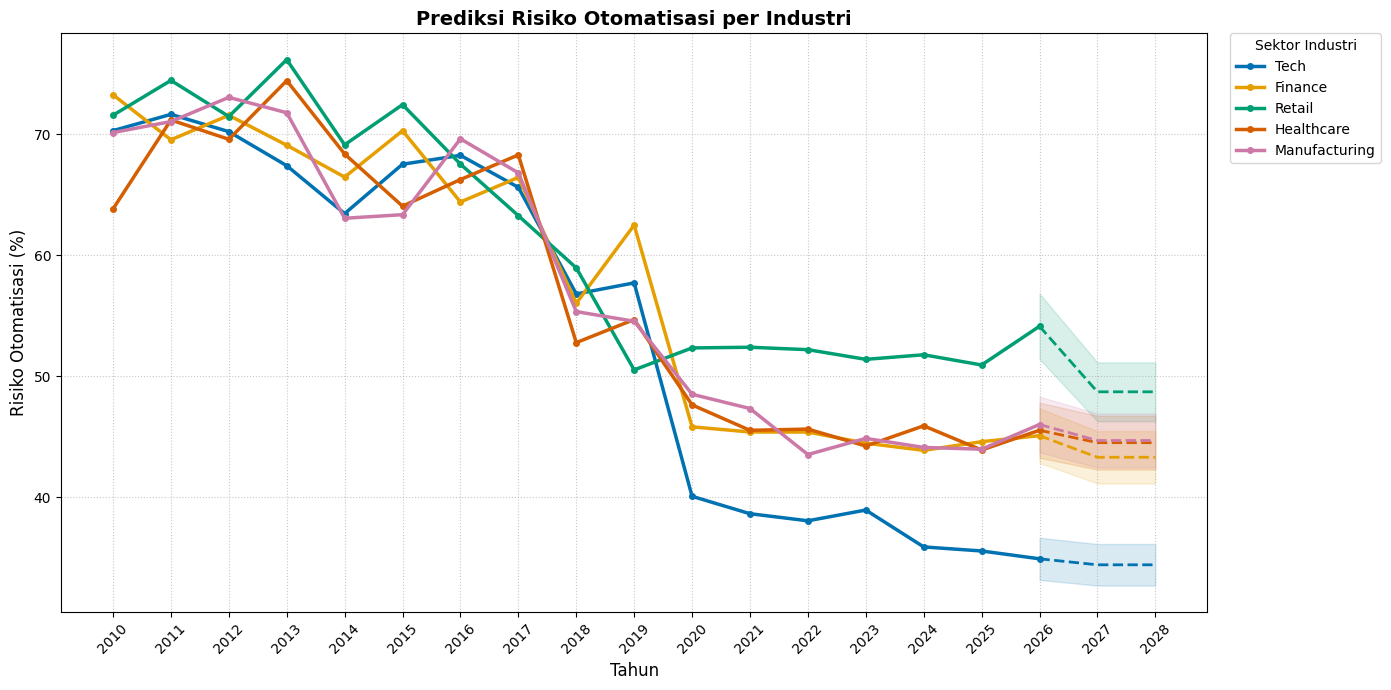

--- Skor Akurasi Model Baru ---
MAE: 2.39
R2 Score: 0.9555

Faktor Paling Berpengaruh:
skill_transition_pressure    0.443723
ai_intensity_score           0.315679
skill_gap_index              0.226478
year                         0.009838
ai_adoption_level            0.001475
dtype: float64


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Load Data
df1 = pd.read_excel('ai_job_replacement_cleaned.xlsx')
df2 = pd.read_excel('ai_impact_jobs_cleaned.xlsx')

# 2. Penyelarasan Variabel & Pembersihan
df1['industry'] = df1['industry'].replace('Technology', 'Tech')
df2['industry'] = df2['industry'].replace('Technology', 'Tech')

df2['automation_risk_percent'] = df2['automation_risk_score'] * 100

df1 = df1.rename(columns={'year': 'year'})
df2 = df2.rename(columns={'posting_year': 'year'})

cols1 = ['year', 'industry', 'automation_risk_percent', 'ai_adoption_level', 'skill_gap_index', 'skill_transition_pressure']
cols2 = ['year', 'industry', 'automation_risk_percent', 'ai_intensity_score']

df_combined = pd.concat([df1[cols1], df2[cols2]], axis=0).reset_index(drop=True)

excluded_industries = ['Education', 'Government', 'Transportation']
df_combined = df_combined[~df_combined['industry'].isin(excluded_industries)]

for col in ['ai_adoption_level', 'skill_gap_index', 'skill_transition_pressure', 'ai_intensity_score']:
    df_combined[col] = df_combined.groupby('industry')[col].transform(lambda x: x.fillna(x.mean()))

df_combined = df_combined.dropna(subset=['automation_risk_percent', 'industry'])
df_combined = df_combined.fillna(df_combined.mean(numeric_only=True))

# 3. Training Model Random Forest
df_model = pd.get_dummies(df_combined, columns=['industry'])
X = df_model.drop('automation_risk_percent', axis=1)
y = df_model['automation_risk_percent']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# 4. Membuat Prediksi 2027-2028
future_years = [2027, 2028]
industries = df_combined['industry'].unique()
future_data = []

for year in future_years:
    for ind in industries:
        col_name = f'industry_{ind}'
        if col_name in df_model.columns:
            feat_avg = df_model[df_model[col_name] == 1].mean()
            feat_avg['year'] = year
            future_data.append(feat_avg)

df_future = pd.DataFrame(future_data).drop('automation_risk_percent', axis=1)
df_future['prediction'] = rf.predict(df_future)

# 5. Visualisasi Fan Chart dengan Warna Kontras Tinggi
plt.figure(figsize=(14, 7))

bright_colors = ['#0072B2', '#E69F00', '#009E73', '#D55E00', '#CC79A7', '#56B4E9', '#F0E442', '#000000']

for i, ind in enumerate(industries):
    color = bright_colors[i % len(bright_colors)]
    
    hist = df_combined[df_combined['industry'] == ind].groupby('year')['automation_risk_percent'].mean().reset_index()
    
    plt.plot(hist['year'], hist['automation_risk_percent'], 
             label=ind, color=color, linewidth=2.5, marker='o', markersize=4)
    
    pred_val = df_future[df_future[f'industry_{ind}'] == 1]
    last_hist = hist[hist['year'] == 2026]
    
    if not last_hist.empty:
        connect_x = [2026, 2027, 2028]
        connect_y = [last_hist['automation_risk_percent'].values[0]] + list(pred_val['prediction'])
        
        plt.plot(connect_x, connect_y, color=color, linestyle='--', linewidth=2)
        
        plt.fill_between(connect_x, [y*0.95 for y in connect_y], [y*1.05 for y in connect_y], 
                         color=color, alpha=0.15)

plt.title('Prediksi Risiko Otomatisasi per Industri', fontsize=14, fontweight='bold')
plt.xlabel('Tahun', fontsize=12)
plt.ylabel('Risiko Otomatisasi (%)', fontsize=12)

plt.xticks(range(2010, 2029), rotation=45) 

plt.grid(True, linestyle=':', alpha=0.7)

plt.legend(title="Sektor Industri", bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)

plt.tight_layout()
plt.show()

# 6. Output Skor dan Importance
y_pred = rf.predict(X_test)
print(f"--- Skor Akurasi Model Baru ---")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.2f}")
print(f"R2 Score: {r2_score(y_test, y_pred):.4f}")
print("\nFaktor Paling Berpengaruh:")
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importances.head(5))